# Task 3 – Geometric Transformations

## Objective

The objective of this task is to understand how geometric transformations modify the position, orientation, and size of an image without changing its content.

### Reference Number

Reference Number: 41

Angle = 41 × 3 = 123°

Scale = 1 + (1 / 10) = 1.1

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [56]:
image = cv2.imread("raw-captures/objects-front.jpg")
print(image)

[[[212 218 223]
  [212 218 223]
  [213 219 224]
  ...
  [197 206 210]
  [198 207 211]
  [198 207 211]]

 [[213 219 224]
  [213 219 224]
  [213 219 224]
  ...
  [198 207 211]
  [198 207 211]
  [198 207 211]]

 [[214 220 225]
  [214 220 225]
  [213 219 224]
  ...
  [199 208 212]
  [198 207 211]
  [197 206 210]]

 ...

 [[ 89 104 137]
  [ 89 104 137]
  [ 90 105 138]
  ...
  [ 89 102 134]
  [ 92 105 137]
  [ 88 101 133]]

 [[ 88 103 136]
  [ 88 103 136]
  [ 90 105 138]
  ...
  [ 88 101 133]
  [ 93 106 138]
  [ 84  97 129]]

 [[ 87 102 135]
  [ 87 102 135]
  [ 90 105 138]
  ...
  [ 84  97 129]
  [ 92 105 137]
  [ 82  95 127]]]


In [58]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

1. Translation
   - Shifted the image horizontally and vertically.

In [61]:
tx = 120
ty = 60

translation_matrix = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

translated = cv2.warpAffine(image_rgb, translation_matrix, (width, height))

2. Rotation
   - Rotated the image about its center using the computed angle.


In [107]:
angle = 123 
scale = 1.1

rotation_matrix = cv2.getRotationMatrix2D(
    (width//2, height//2),
    angle,
    scale
)

rotated = cv2.warpAffine(
    image_rgb,
    rotation_matrix,
    (width, height)
)

3. Scaling
   - Increased the image size using the calculated scale factor.

In [110]:
scaled = cv2.resize(
    image_rgb,
    None,
    fx=scale,
    fy=scale,
    interpolation=cv2.INTER_LINEAR
)
print("Original Size :", image_rgb.shape)
print("Scaled Size   :", scaled.shape)

Original Size : (4608, 2592, 3)
Scaled Size   : (5069, 2851, 3)


4. Affine Transformation
   - Applied a linear transformation using three corresponding points, causing skewing while preserving straight lines.


In [113]:
pts1 = np.float32([
    [100,100],
    [500,100],
    [100,600]
])

pts2 = np.float32([
    [50,150],
    [520,80],
    [150,650]
])

affine_matrix = cv2.getAffineTransform(
    pts1,
    pts2
)

affine = cv2.warpAffine(
    image_rgb,
    affine_matrix,
    (width,height)
)

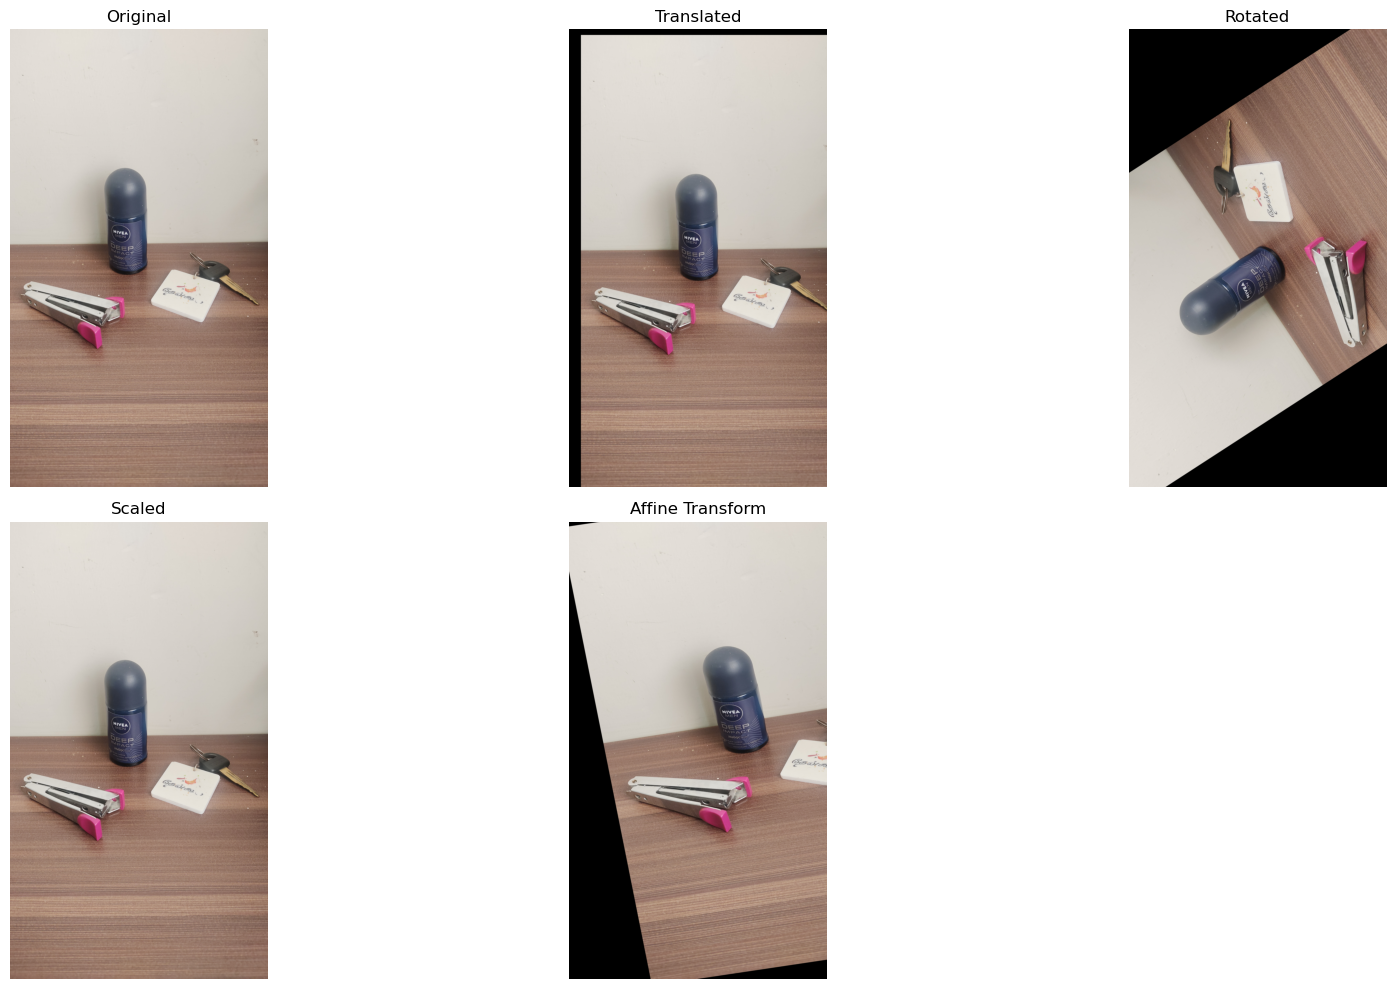

In [115]:
plt.figure(figsize=(18,10))

plt.subplot(231)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(232)
plt.imshow(translated)
plt.title("Translated")
plt.axis("off")

plt.subplot(233)
plt.imshow(rotated)
plt.title("Rotated")
plt.axis("off")

plt.subplot(234)
plt.imshow(scaled)
plt.title("Scaled")
plt.axis("off")

plt.subplot(235)
plt.imshow(affine)
plt.title("Affine Transform")
plt.axis("off")

plt.tight_layout()
plt.show()

## Observations

- **Translation:** The entire image shifted horizontally and vertically without changing the size or orientation of the objects. Black borders appeared where no pixel data was available after shifting.

- **Rotation:** The image was rotated by **123°** around its center with a scale factor of **1.1**. Black triangular regions appeared because parts of the rotated image extended outside the original frame.

- **Scaling:** The image was enlarged using a scale factor of **1.1**. The objects became slightly larger while maintaining their proportions.

- **Affine Transformation:** The image was skewed by mapping three source points to three destination points. The relative geometry changed, but straight lines remained straight, demonstrating the effect of an affine transformation.

In [4]:
!git status

On branch master
nothing to commit, working tree clean
